# Potential Production

In this example we use PalmSim to explore the **potential production** of differents sites **based on solar radiation** alone.

We will consider a site in **Bangladesh, north Sumatra, south Sumatra and south Kalimantan**.

### What we expect

We expect the yield to go up with the amount of solar radiation.

Thus we expect the site with the highest amount of radiation to have the highest yields.

Furthermore, we expect the strongest variation in yield for the site with the strongest variation in radiation.


### This Example   

This example has the following outline:

    1. We have a look at the input **weather data**.
    2. We consider the potential bunch yields.
    3. We compare the sites.
 

## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

# read-in the csv-files

import os
file_dir = os.path.join('.','input')

weather_data = {}

# load all the files in the input directory
for file in os.listdir(file_dir):
    if file.endswith('.csv'):
        
        filename,ext = file.split('.')
        filepath = os.path.join(file_dir,file)

        df = pd.read_csv(filepath,index_col='Date')
        df.index = pd.to_datetime(df.index)
        
        weather_data[filename] = df

In [2]:
list(weather_data)

['bangladesh', 'north_sumatra', 'south_kalimantan', 'south_sumatra']

#### Note the quite variable solar radiation

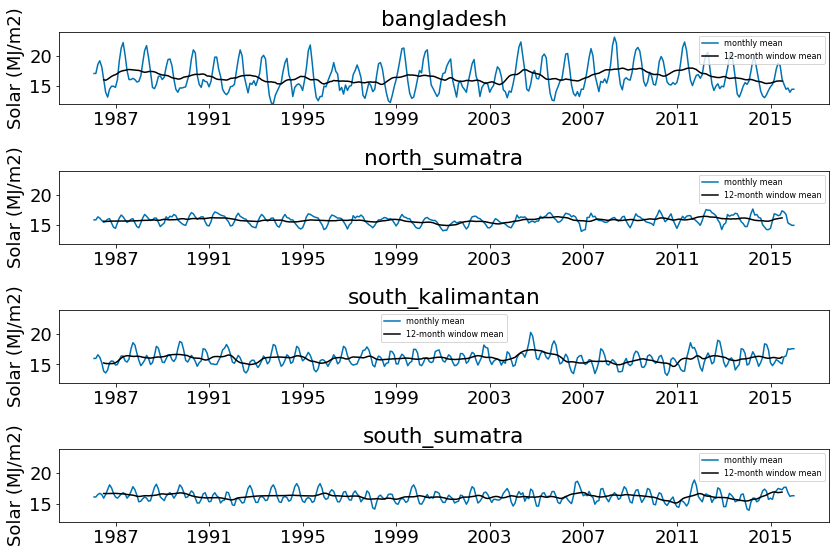

In [3]:
from plotting import tsplot, add_highlight

f,axes = plt.subplots(len(weather_data), figsize=(12,8))

for ax,site in zip(axes,weather_data):

    f,ax = tsplot(weather_data[site],'Solar (MJ/m2)',ax=ax)
    ax.set_ylim(12,24)
    ax.set_title(site)
    
plt.tight_layout()

### Bangladesh seems sunny

Note the relatively sunny and seasonal weather of Bangladesh compared to the rest.

Unfortunately Bangladesh has strong periodic droughts...

So for actual production, not ideal (unless you have irrigation).

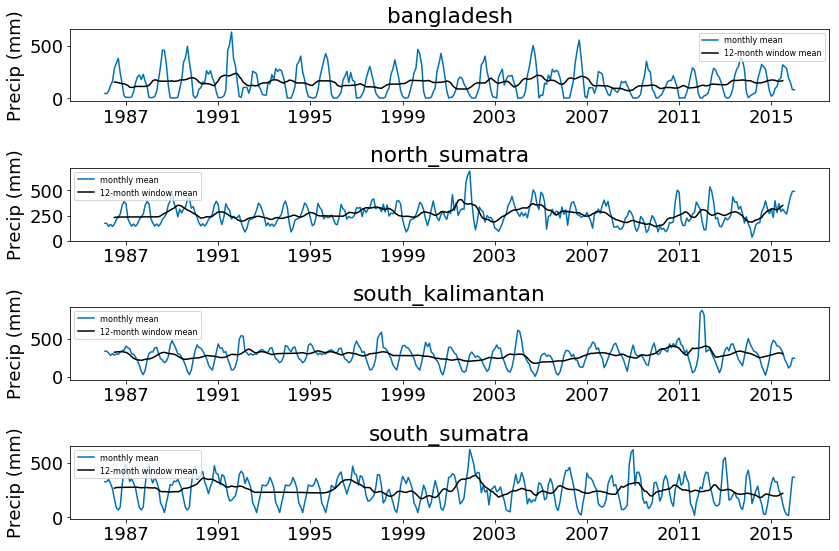

In [4]:
from plotting import tsplot, add_highlight

f,axes = plt.subplots(len(weather_data), figsize=(12,8))

for ax,site in zip(axes,weather_data):

    f,ax = tsplot(weather_data[site],'Precip (mm)',ax=ax)
    ax.set_title(site)
    
plt.tight_layout()

## Potential Yield

Now let us **run PalmSim**, first given the **mean solar radiation data**.

In [5]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

results = {}
print('Mean radiation:')
for site in weather_data:
    
    year_of_planting = weather_data[site].index.year[0]

    # 1. Initialize the model
    p = PalmField(year_of_planting=year_of_planting)

    # 2. Couple the solar radiation data:
    mean_solar_radiation = weather_data[site]['Solar (MJ/m2)'].mean()
    
    
    print('{:}: {:}'.format(site,mean_solar_radiation))
    
    p.weather.radiation_series = [mean_solar_radiation]

    # 3. Run the model
    df = p.run(duration=360,)
    
    results[site] = df

Mean radiation:


AttributeError: 'Fronds' object has no attribute '_prefix'

#### Viewing the results

Running PalmSim returns a spreadsheet which can be viewed directly and can be saved as an Excel spreadsheet (.csv).

Let us visualize the results directly.


In [ ]:
from plotting import tsplot, add_highlight

f,axes = plt.subplots(len(weather_data), figsize=(12,16))

for ax,site in zip(axes,results):

    f,ax = tsplot(results[site],'organs yield FM yearly (tonne FM/ha/year)',ax=ax)
    ax.set_ylabel('FFB yield (t/ha/yr)')
    ax.set_ylim(0,50)
    ax.grid()
    ax.set_title(site)
    
plt.tight_layout()

## Potential Yield

Now let us run PalmSim given the actually **variable solar radiation**.

In [ ]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from PalmField import PalmField

results = {}
print('Radiation: mean,std')
for site in weather_data:
    
    year_of_planting = weather_data[site].index.year[0]

    # 1. Initialize the model
    p = PalmField(year_of_planting=year_of_planting)

    # 2. Couple the solar radiation data:
    mean_solar_radiation = weather_data[site]['Solar (MJ/m2)'].mean()
    std_solar_radiation = weather_data[site]['Solar (MJ/m2)'].std()
    
    print('{:}: {:<3.3f}, {:<3.3f}'.format(site,mean_solar_radiation,std_solar_radiation))
    
    p.weather.radiation_series = weather_data[site]['Solar (MJ/m2)'].values

    # 3. Run the model
    df = p.run(duration=360,)
    
    results[site] = df

In [ ]:
from plotting import tsplot, add_highlight

f,axes = plt.subplots(len(weather_data), figsize=(12,16))

for ax,site in zip(axes,results):

    f,ax = tsplot(results[site],'organs yield FM yearly (tonne FM/ha/year)',ax=ax)
    ax.set_ylabel('FFB yield (t/ha/yr)')
    ax.set_ylim(0,80)
    ax.grid()
    ax.set_title(site)
    
plt.tight_layout()

In [ ]:
fdf = results['north_sumatra']
df = pd.DataFrame()

In [ ]:
bs = 20

df['yield'] = bs*fdf['yield FM yearly (tonne FM/ha/year)']
df['bunch count'] = bs*fdf['organs bunch count (1/ha/month)']
df['bunch weight'] = 100*df['yield']/df['bunch count']

In [ ]:
df['bunch weight'].plot()

In [ ]:
df.round(1).to_excel('temp.xlsx')

#### Note the variation in yield weight in response to the solar radiation.

### Conclusion

This concludes this example.

In [ ]:
plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')

In [ ]:

fig,ax = plt.subplots(figsize=(8,6))

df = results['south_kalimantan']

x = (1/12)*df['MAP'].values
y = df['organs yield FM yearly (tonne FM/ha/year)'].values

yM = df['organs yield FM yearly (tonne FM/ha/year)'].mean()

ax.plot(x,y,color='black')

ax.set_xlabel('Years after planting (yr)')
ax.set_ylabel('FFB Yield (t FM/ha/yr)')

ax.set_xlim(0,25)
ax.set_ylim(0,55)

ax.axhline(yM,color='black',ls='dashed', label='Life-span mean')
#ax.set_title('Potential Yield Est. for a site in S. Kalimantan')
ax.grid(True)
ax.legend()

plt.savefig('../../communication/poster IOPRI/potential.png',dpi=300)

In [ ]:

fig,ax = plt.subplots(figsize=(8,6))

df = results['south_kalimantan']

x = df.index.values
y = df['organs yield FM yearly (tonne FM/ha/year)'].values

yM = df['organs yield FM yearly (tonne FM/ha/year)'].mean()

ax.plot(x,y,color='black')

ax.set_xlabel('Year (yr)')
ax.set_ylabel('FFB Yield (t FM/ha/yr)')

ax.set_ylim(0,55)

ax.axhline(yM,color='black',ls='dashed', label='Life-span mean')
#ax.set_title('Potential Yield Est. for a site in S. Kalimantan')
ax.grid(True)
ax.legend()

plt.savefig('../../communication/poster IOPRI/potential2.png',dpi=300)